<a href="https://colab.research.google.com/github/TirthhShethh/Deep-Learning/blob/DL-1/base_dl.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**We want to write a program that looks at a small image (28x28 pixels) of a handwritten number and correctly identifies whether it is a 0, 1, 2, ... or 9.**

In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt

In [2]:
mnist = tf.keras.datasets.mnist
(x_train, y_train),(x_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


**x_train: The images we train with (60,000 images)**

**y_train: The correct answers (labels) for those images**

**x_test:  The images we will test the model on later**

**Computers like numbers between 0 and 1. Images are usually stored as numbers between 0 (black) and 255 (white). We simply divide by 255 to "normalize" them.**

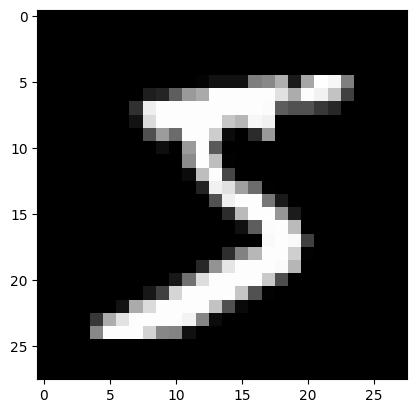

Correct Label: 5


In [3]:
x_train, x_test = x_train / 255.0, x_test / 255.0
plt.imshow(x_train[0], cmap='gray')
plt.show()
print(f"Correct Label: {y_train[0]}")

**Build the Brain (The Neural Network)
This is where we define the structure of our AI.**

In [4]:
model = tf.keras.models.Sequential([
  # Layer 1: Flatten
  # Takes the 28x28 square image and unstack it into a single line of 784 pixels.
  tf.keras.layers.Flatten(input_shape=(28, 28)),

  # Layer 2: Dense (Hidden Layer)
  # 128 "neurons" that will learn to recognize patterns (curves, lines, loops).
  # 'relu' is a math function that helps the model learn non-linear patterns.
  tf.keras.layers.Dense(128, activation='relu'),

  # Layer 3: Dropout
  # Randomly turns off 20% of neurons during training to prevent "over-memorizing".
  tf.keras.layers.Dropout(0.2),

  # Layer 4: Output Layer
  # 10 neurons (one for each digit 0-9).
  # 'softmax' converts the output into probabilities (e.g., 90% chance it's a '5').
  tf.keras.layers.Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


**We tell the model how to learn.
Optimizer (adam): The algorithm that adjusts the math to improve predictions.
Loss Function: A generic way to calculate "how wrong" the model is.
Metrics: We want to track "accuracy" (percentage of correct guesses)**

In [5]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

**This is the magic part. The model looks at the data, makes a guess, checks if it was right, and adjusts its internal math. It does this 5 times (epochs=5) over the whole dataset**

In [6]:
# Train the model
model.fit(x_train, y_train, epochs=5)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8591 - loss: 0.4797
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9539 - loss: 0.1586
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9669 - loss: 0.1097
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9736 - loss: 0.0873
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9772 - loss: 0.0732


**Now we show the model the x_test images (which it has never seen before) to see if it actually learned, or just memorized the training data.**

In [7]:
model.evaluate(x_test,  y_test, verbose=2)

313/313 - 1s - 2ms/step - accuracy: 0.9766 - loss: 0.0737


[0.07372181862592697, 0.9765999913215637]

In [33]:
import numpy as np

# 1. Pick a random image from the test set
image_index = 0 # You can change this number to check different images!
selected_image = x_test[image_index]
true_label = y_test[image_index]

In [34]:
# 2. Make the model predict
# We need to reshape the image because the model expects a batch of images, not just one.
# (1, 28, 28) means "1 image, 28 pixels high, 28 pixels wide"
prediction_scores = model.predict(selected_image.reshape(1, 28, 28))
predicted_label = np.argmax(prediction_scores)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step


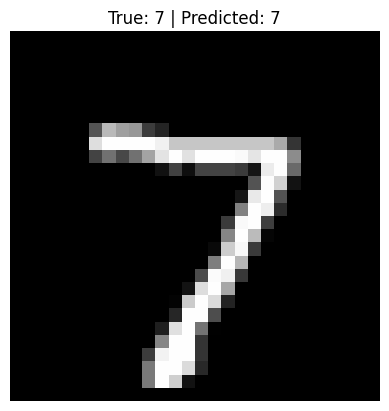

In [35]:
# 3. Show the results
plt.imshow(selected_image, cmap='gray')
plt.title(f"True: {true_label} | Predicted: {predicted_label}")
plt.axis('off') # Hide the axis numbers for a cleaner look
plt.show()

In [32]:
print(f"Confidence Scores: {prediction_scores}")

Confidence Scores: [[2.6781530e-07 2.4711498e-04 9.9928266e-01 1.6527521e-04 1.7153669e-05
  6.6963304e-07 1.8416323e-08 2.6879416e-04 1.7774317e-05 3.3897990e-07]]
